### Student Performance & Study Habits Dataset
i've picked a dataset at random(mostly) to illustrate a potential data science workflow. this dataset has features that make it great for one of the two main tasks of supervised machine learning; classification; assigning a label. the other one is regression; predicting a continuos value.

if you look back at the previously shared notes there was mention of **features** and **targets**. in super simple "classification/labelling terms"; you've got a picture paired with its name. the appropriate algortithm is fed this (input-output) pair from which it builds 'statistical intuition' on the relationship between a picture and a name. with enough **input-output pairs** the trained algorithm/model has a more robust intuition and can identify new pictures (new input) and give the correct label/name (new output).

with the Student Performance & Study Habits dataset every column is a feature that helps us predict our target in the `final_grade` column. though we have A through F as possible labels we'll make some choices on 'thresholds'(look up **decision boundaries**) for passing and failing grades to reduce 'target space' by converting a **multi-class classification** problem (A, B, C, D, F) to a **binary classification** problem (Pass:1 vs. Fail:0).

- our problem is a **binary classification** problem (a sample can either the a pass or a fail). we'll be using different features (different pieces of information on a student) to predict whether they'll pass or fail.

- we'll be using the [Student Performance & Study Habits Dataset](https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset/discussion/734497) gotten from kaggle as a csv file which includes both our features and target variable.
- other common formats supported by pandas are excel, json, sql and parquet. explore the pandas documentation to discover more compatible formats and read functions.

- usually an **evaluation metric** defined early on but it can change over time. this gives you a rough goal to work towards as a data scientist or machine learning engineer.
- we could say for example that `if we can predicting whether or not a student fails with 90% accuracy then we have a usable model worth looking into further.`

- to get as close as we can to our evaluation metric we need to select which features/columns matter to us/our problem. you can create a reference for each of the features in your notebook using markdown or for this project refer to the data card on the kaggle website for the dataset which contains the feature name, feature description and example values.
- in the real world not all datasets come with this so you may need to as an expert or have domain knowledge yourself (or ask ai).

we'll begin by importing all* the necessary libraries.

*as the project progresses new libraries may be imported and can be added to our initial block of import statements.

In [94]:
# standard EDA and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# models (one for each; supervised and unsupervised)
from sklearn.linear_model import LogisticRegression # a classifier
from sklearn.ensemble import RandomForestClassifier # okay another classifier
from sklearn.cluster import KMeans                  # a clustering algorithm

# model evaluators; performance checkers
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

In [95]:
df = pd.read_csv("student_performance_dataset.csv")
df.head(10) # quick glance at our DataFrame; alternatively plain df works just fine

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


once we've imported our dataset, we explore it to familiarize ourselves with the data, its components and how they relate to each other. the formal term for this is **Exploratory Data Analysis(EDA)**.

from [elsewhere](https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-3-structured-data-projects/end-to-end-heart-disease-classification.ipynb);
since EDA has no real set methodolgy, the following is a short check list you might want to walk through:
1. what question(s) are you trying to solve (or prove wrong)?
2. what kind of data do you have and how do you treat different types?
3. what’s missing from the data and how do you deal with it?
4. where are the outliers and why should you care about them?
5. how can you add, change or remove features to get more out of your data?

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [97]:
df.isna().sum() / len(df) * 100

# df.isna() detects missing values and returns a DataFrame of booleans; False for non-null and True for null.isinstance
# .isna just asks the question "is it null?"
# df.isna().sum() aggregates the null values; adds all the 'Trues' per column
# len(df) just returns the total number of rows in the df
# the entire line of code computes 'missing / total * 100' to return the percentage of missing values.
# i think its neat 😃. 


student_id                     0.0
gender                         0.0
study_time_hours               0.0
attendance_percent             0.0
sleep_hours                    0.0
parental_education            10.2
internet_access                0.0
extracurricular_activities     0.0
part_time_job                  0.0
previous_grade                 0.0
final_exam_score               0.0
final_grade                    0.0
dtype: float64

we quickly see that our dataset is almost 100% complete with the correct data type for each column. the exception is the `parental_education` column with a little over 10% of values missing. given the feature we can 'guess' that some parents may have been hesitant to share this information for various reasons. and given the **missingness** we can choose to drop the null values because as we'll still have plenty of data to work with.

you can try your hand at an appropriate imputing method after the first run of the project.

In [98]:
df.dropna(subset=['parental_education'], inplace=True)

# dropna() drops an entire row if any single feature is null
# the subset=[''] parameter is used when we want to drop rows only where the specified column is null
#inplace=True makes this change on our current DataFrame; doesn't make a copy

In [99]:
df.duplicated().sum()

# duplicated() works similar to isna() by checking for duplicates and returning booleans
# adding sum() to it returns the total number of duplicates/duplicate rows in our dataset
# if we did have duplicates we could delete them using the drop_duplicates() method

np.int64(0)

In [100]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000
mean,498.606904,3.563586,84.986526,6.808241,69.641648,83.555791
std,288.173896,1.469678,9.381879,1.216451,12.589308,10.345629
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,248.250000,2.600000,78.800000,5.900000,60.900000,76.100000
50%,495.500000,3.500000,85.150000,6.800000,69.600000,83.800000
75%,746.750000,4.500000,91.975000,7.600000,78.400000,91.575000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


### Some Math (concepts) Worth Knowing
**mean**: sum of all total values divided by total number of values
**50%; 50th percentile**: the value where 50% of data falls below it and 50% of data falls above it; the median
**std; standard deviation**: average distance of data points from the mean

- **mean vs median**: the mean and the median will be almost identical if our data has no outliers. when **outliers**(unusually large or unusually small values) are present in our data they pull the mean away from the median; skew our data.
- when **mean >> median**(significantly higher) there's likely a large positive outliers pulling the average up.
- **standard deviation rule**:any data point that lies more than 3 standard deviations away from the mean is mathematically considered an outlier (*idk either gng ❤️‍🩹️✌🏾️*)

In [101]:
df.final_grade.value_counts().sort_index()

final_grade
A    255
B    320
C    232
D     80
F     11
Name: count, dtype: int64

In [102]:
# let's convert the letter grades to a binary target (Pass/Fail) using a lambda function

df['passed'] = df['final_grade'].apply(lambda grade: 1 if grade in ['A', 'B', 'C'] else 0)

a lambda function is a single use anonymous function. no name so isn't callable (refer to notes?)
### lambda args : expression
**lambda** is a python keyword (WK 1 classes) that creates anonymous functions. as with other python functions;
`args` is the argument or parameter the function accepts and the `expression` is the equivalent of the function body; the code executed when you call a function

the lambda function above takes a `grade` and looks it up in the list of grades `['A', 'B', 'C']`, if the grade is in the list the `1` is returned otherwise `0` is returned in a new column `passed`. using the **apply()** method instead of an explicit for loop speeds things up quite a bit.

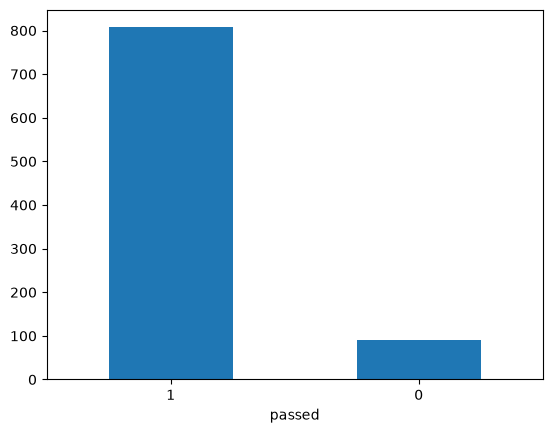

In [103]:
df.passed.value_counts().plot(
    kind='bar')
plt.xticks(rotation=0)    
plt.show()

if we were to split our data into pass and fail classes with A, B & C as pass and D & F as fail we'd have 899 samples in the pass class and 101 samples in the fail class. in an ideal world all of our target classes have the same number of samples (so that the model is equally good at identifying/labelling either class).

In [104]:
print(f"""after splitting our data into fail and pass classes we have a pass class with a sample size of {len(df[df.passed==1])}
and a fail class with a sample size of {len(df[df.passed==0])}. i'm including this python code to show that 'hard-coded' values aren't always the best option;
in the markdown cell above my sample sizes were calculated before we dropped nulls in the parental_education column.

using an f-string i can add code or variable names inside curly braces that update in real-time as values change!""")

after splitting our data into fail and pass classes we have a pass class with a sample size of 807
and a fail class with a sample size of 91. i'm including this python code to show that 'hard-coded' values aren't always the best option;
in the markdown cell above my sample sizes were calculated before we dropped nulls in the parental_education column.

using an f-string i can add code or variable names inside curly braces that update in real-time as values change!


### Exploring Relationships between Variables
while we could begin making comparisons between certain features and our targets (and you(you specifically) can) e.g. study_time_hours and passed (*does more studying lead to better results?*) or extracurricular_activites and study_time_hours or passed (*do extracurricular studies take away from study time or affect performance?*) to draw some inference, i'll jump straight to using a **correlation matrix** to see the extent to which each feature/independent variable impacts our target variable (because i'm tired and want to stop for today soon).

a correlation matrix; corr_matrix, is simply a big table of numbers telling us how related each variable is to the another. trouble is... it only work with numeric types.

we'll start by 'fixing' the binary columns; Yes/No and Male/Female columns; first error i got was a `ValueError: could not convert string to float: 'Male'` 

In [105]:
binary_cols = ['internet_access', 'extracurricular_activities', 'part_time_job']
df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0})
# and
df.gender = df.gender.replace({'Male': 1, 'Female': 0}) # replace() is a pretty straightforward method

df.head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,passed
0,1,1,4.0,98.0,6.5,Bachelors,1,1,0,76.9,100.0,A,1
1,2,0,6.3,100.0,5.7,High School,1,1,1,75.5,100.0,A,1
2,3,1,4.9,85.3,7.9,Bachelors,1,0,1,88.5,97.3,A,1
4,5,1,2.2,89.6,4.6,Bachelors,1,0,1,61.8,68.3,D,0
5,6,0,4.2,78.2,5.7,High School,1,0,0,79.8,81.6,B,1
6,7,1,1.5,100.0,5.0,High School,1,1,1,58.6,69.6,D,0
7,8,1,6.2,86.4,6.0,High School,1,1,0,78.4,88.0,B,1
8,9,1,5.3,81.3,6.7,Bachelors,1,0,0,63.8,84.4,B,1
9,10,0,2.8,86.8,5.1,Bachelors,1,1,0,57.7,74.3,C,1
10,11,1,0.9,71.5,5.7,High School,1,0,1,73.4,68.9,D,0


what remains is `parental_education` and `final_grade`. both of which are **ordinal categories**; categories that have an inherent order; education levels, test scores. we need to assign meaningful numeric ranks so that the correlation matrix captures the relationship accurately.

In [106]:
df.parental_education.unique() # to get the distinct education levels

<StringArray>
['Bachelors', 'High School', 'Masters', 'PhD']
Length: 4, dtype: str

In [107]:
df.final_grade.unique() # to get the distinct grades

<StringArray>
['A', 'D', 'B', 'C', 'F']
Length: 5, dtype: str

In [108]:
education_order = {
    "High School": 1,
    "Bachelors": 2,
    "Masters": 3,
    "PhD": 4
}
# we create a dictionary with a logical ranking of identified education levels before mapping values
# in the column to the keys(rank number) in the dictionary using the map() method
df['parental_education_num'] = df.parental_education.map(education_order)

# on to the grade with a logical ranking of present grades. grade A has a higher value/ranks higher
# if this assumption ends up to be faulty we could always make changes to the dictionary
scored_grade = {
    "A": 5,
    "B": 4,
    "C": 3,
    "D": 2,
    "F": 1
}
df['grade_num'] = df.final_grade.map(scored_grade)

df.head(10)


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,passed,parental_education_num,grade_num
0,1,1,4.0,98.0,6.5,Bachelors,1,1,0,76.9,100.0,A,1,2,5
1,2,0,6.3,100.0,5.7,High School,1,1,1,75.5,100.0,A,1,1,5
2,3,1,4.9,85.3,7.9,Bachelors,1,0,1,88.5,97.3,A,1,2,5
4,5,1,2.2,89.6,4.6,Bachelors,1,0,1,61.8,68.3,D,0,2,2
5,6,0,4.2,78.2,5.7,High School,1,0,0,79.8,81.6,B,1,1,4
6,7,1,1.5,100.0,5.0,High School,1,1,1,58.6,69.6,D,0,1,2
7,8,1,6.2,86.4,6.0,High School,1,1,0,78.4,88.0,B,1,1,4
8,9,1,5.3,81.3,6.7,Bachelors,1,0,0,63.8,84.4,B,1,2,4
9,10,0,2.8,86.8,5.1,Bachelors,1,1,0,57.7,74.3,C,1,2,3
10,11,1,0.9,71.5,5.7,High School,1,0,1,73.4,68.9,D,0,1,2


In [109]:
# the student_id does nothing for us! so we'll delete it
# we could have set it as the index while loading our data it but there's no need to do that at this point

corr_df = df.drop(columns='student_id')
corr_matrix = corr_df.corr(numeric_only=True)
corr_matrix

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,passed,parental_education_num,grade_num
study_time_hours,1.000000,-0.038170,-0.000487,-0.018763,0.569709,0.298420,0.047856,0.528538
attendance_percent,-0.038170,1.000000,0.042109,-0.027596,0.259429,0.177282,0.011536,0.249324
sleep_hours,-0.000487,0.042109,1.000000,-0.004852,0.148645,0.082709,-0.020165,0.135196
previous_grade,-0.018763,-0.027596,-0.004852,1.000000,0.408702,0.191597,-0.011648,0.381499
final_exam_score,0.569709,0.259429,0.148645,0.408702,1.000000,0.605018,0.042177,0.954850
passed,0.298420,0.177282,0.082709,0.191597,0.605018,1.000000,0.064087,0.657540
parental_education_num,0.047856,0.011536,-0.020165,-0.011648,0.042177,0.064087,1.000000,0.061636
grade_num,0.528538,0.249324,0.135196,0.381499,0.954850,0.657540,0.061636,1.000000


i'm noticing that we have some repetitive columns/columns representing the same thing differently(`final_grade` and `passed` for example) that are giving us us 'false positives'. identify them if you want ✌🏾️🥀️

i'll delete them next time. exhausted. see you on wednesday if you want.

In [110]:
# we'll immediately pick up where we left off; dropping/deleting repetitive columns and reordering our final columns

repetitive_cols = ['parental_education', 'final_grade']
corr_df = corr_df.drop(columns=repetitive_cols)

corr_df = corr_df[[
    'gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'internet_access', 'extracurricular_activities', 'part_time_job', 
    'parental_education_num','previous_grade', 'final_exam_score', 'grade_num', 'passed']]

corr_df.columns

Index(['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours',
       'internet_access', 'extracurricular_activities', 'part_time_job',
       'parental_education_num', 'previous_grade', 'final_exam_score',
       'grade_num', 'passed'],
      dtype='str')

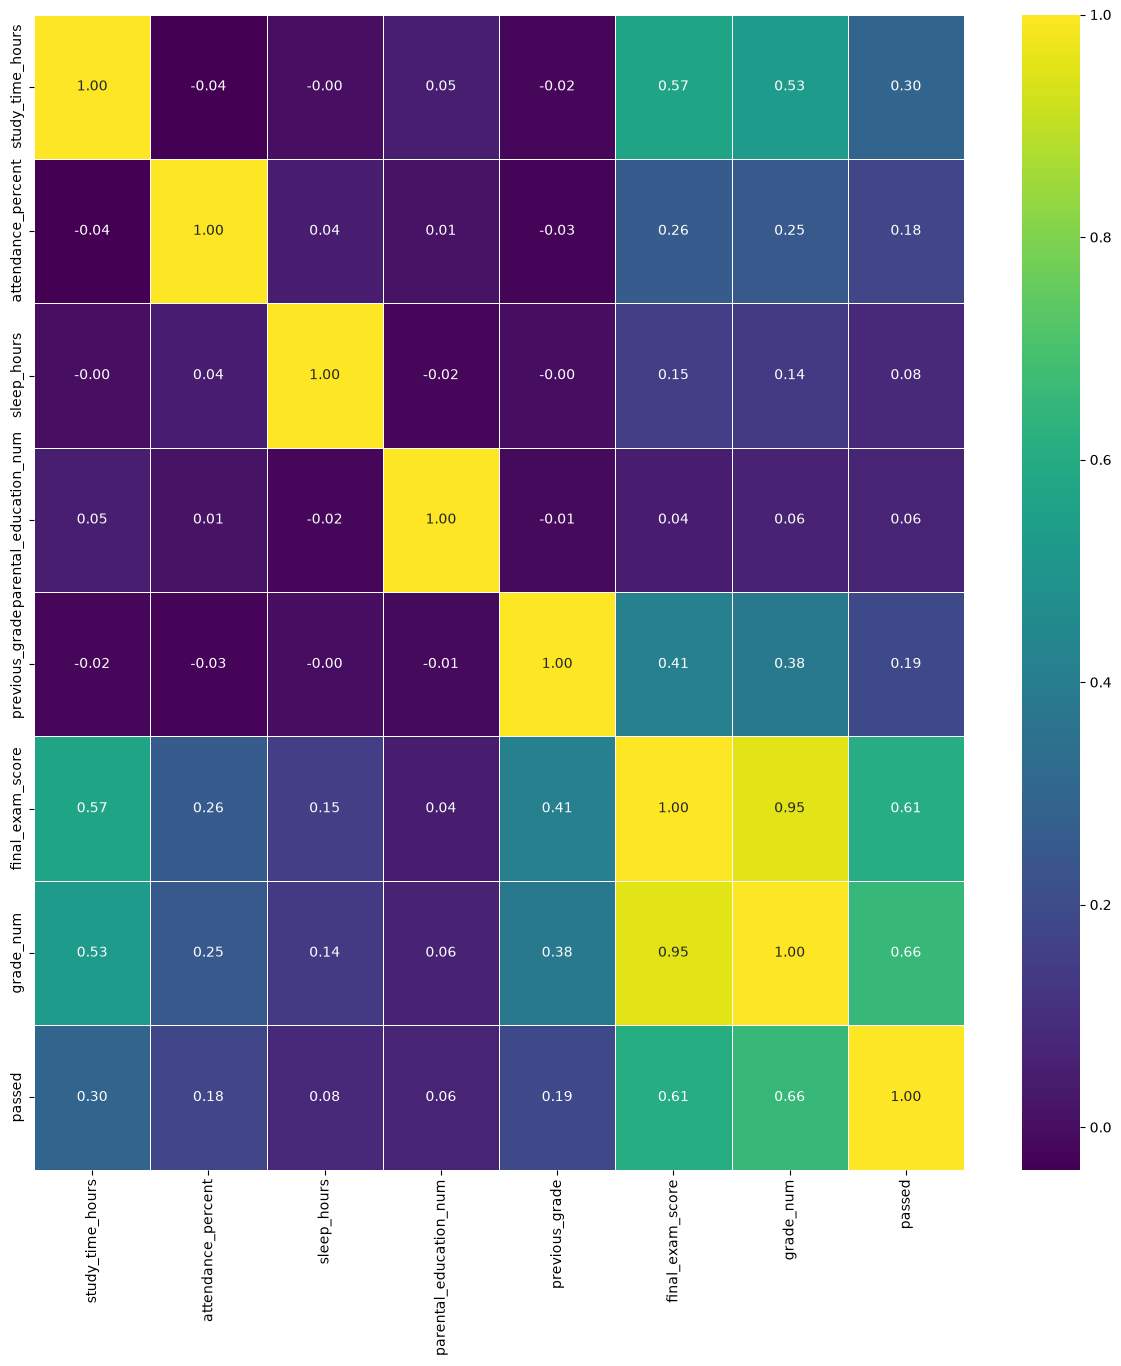

In [111]:
# let's recreate our correlation matrix and visualize

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, 
            annot=True, 
            linewidths=0.5,
            fmt=".2f",
            cmap="viridis")
            
plt.show()

### Data Leakage
even with the dropped columns we still have; `final_exam_score`, `grade_num`, .

unlike the columns we already dropped we should be wary of including these in `X` (refer to ml-stuff..pdf) when modeling as the model won't really 'learn the relationship' we're trying to get it to learn; `whether a student will pass or fail based on their habits and other relevant/available metrics`. it will already have the answers in the form of the final exam scores and grades.

on to modeling!

### Modeling
it's time to split our target variable (`passed`) from the features before reuniting with train_test_split.

- `X` - our features
- `y` - our target variable

In [112]:
X = corr_df.drop(columns=['final_exam_score', 'grade_num', 'passed'])
y = corr_df.passed

In [113]:
X.head(3)

,gender,study_time_hours,attendance_percent,sleep_hours,internet_access,extracurricular_activities,part_time_job,parental_education_num,previous_grade
0,1,4.0,98.0,6.5,1,1,0,2,76.9
1,0,6.3,100.0,5.7,1,1,1,1,75.5
2,1,4.9,85.3,7.9,1,0,1,2,88.5


In [114]:
y.head(3)

0    1
1    1
2    1
Name: passed, dtype: int64

### train_test_split
scikit-learn has a module `sklearn.model_selection.train_test_split()` which as the descriptive name suggests splits our data into two, a training set and a testing set.
- from the `training set` the model learns the patters in the dataset to be able to make predictions on similar but unseen samples
- it is on the `testing set` that trained model is evaluated; this is the first batch of 'similar but unseen samples' from which data scientists and ml engineerings find out whether the model is any good at making predictions accurately before deploying it/making it publicly* available for use.

the split is usually roughly a **70-30/80-20** percent of the dataset for training and testing respectively

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2
)

print(f"""
{len(X_train)},{len(y_train)}; training features and training targets

{len(X_test)},{len(y_test)}; testing features and testing targets
""")


718,718; training features and training targets

180,180; testing features and testing targets



everything looks balanced. on to
### Model Selection
we're familiar with our problem; a classification problem. the scikit-learn library and machine learning in general has multiple models from which we can choose for a particular problem. data science and ml is an **iterative process**; we can have multiple different runs/attempts to reach a solution and pick the best one/the one that gets us as close as possible to our desired outcome.

you'll familiarize yourself with more of these tools as you spend more time learning and working on different projects. there's some nuance to model selection even if they all perform the same type of task. for this data i've selected **Logistic Regression** and **Random Forest Classifier**.

tl;dr: when you're starting out prioritize understanding your problem first followed by what tools are available to solve that specific problem.

we'll try out both models in one go and score them (rate them on accuracy) to pick one to continue working with/improving on.


In [116]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Random Forest": RandomForestClassifier()
}

# in ml-stuff..pdf there's an 'outline' of what training a model; fitting, is like;
# model = LogisticRegression()
# model.fit(X_train, y_train)
# predictions = model.predict(X_test)
# we'll write a function that makes use of a for loop to loop over model in models
#  and 'fits' them on our splits (we need both the train and test splits) then returns their respective scores

def model_fitter_scorer(models, X_train, X_test, y_train, y_test):
    """
    remeber docstrings? you can add one to this function
    """

    np.random.seed(42)
    model_scores = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)  # fit/train the model on the data
        model_scores[name] = model.score(X_test, y_test) # evaluate the model and append its score to model_scores
    return model_scores


# fitting; the model attends class, learns
# scoring; the model takes a test to prove it's learned and there's a marking scheme to check against
# now we have a callable function 😃

In [117]:
model_scores = model_fitter_scorer(models=models,
                    X_train=X_train,
                    X_test=X_test,
                    y_train=y_train,
                    y_test=y_test) # my suspicion is that there's a more elegant way to write this function

model_scores

{'Logistic Regression': 0.9, 'Random Forest': 0.8833333333333333}

### Model Comparison 
let's make another visual for comparison (you might be working with more than two models in the future with varying scores)

we'll use the `DataFrame` constructor (refer to Pandas first class) to create a DataFrame from our model_scores dictionary make a plot from that. (one of the most "popular" ways to demonstrate making a DataFrame is by using a dictionary)

In [118]:
print(f"well damn! we hit {model_scores[list(model_scores)[0]]:.2f} and {model_scores[list(model_scores)[1]]:.2f} accuracy right off the bat with both models.")

# :.2f rounds the values off to 2 decimal points... or is it 2 floating points?
# the full colon is just syntax

well damn! we hit 0.90 and 0.88 accuracy right off the bat with both models.


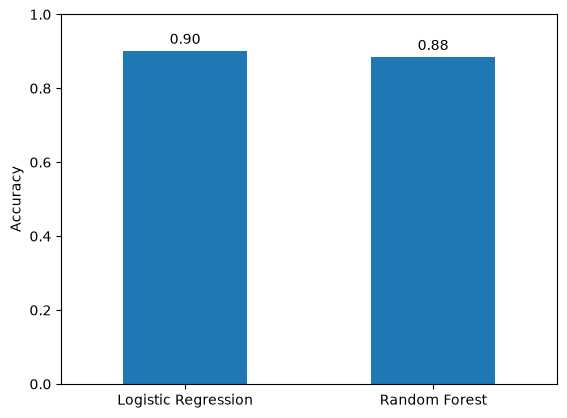

In [119]:
model_scores_df = pd.DataFrame(model_scores, index=['accuracy'])

ax = model_scores_df.T.plot.bar(legend=False)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3) # for readability
plt.ylim(0, 1) # so that our labels aren't cut off
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

### So how'd it go ?
our findings show that Logistic Regression is the best algorithm for predicting whether a student fails or passes with 93% accuracy. and we got such a high score without having to worry about **hyperparameter tuning**!

quick question though... is accuracy all we need to consider when training our classification algorithms?

we'll stop here for today i guess.